In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy.ma.core import minimum
from src import metricas as m
import numpy as np

In [2]:
# Cargar bases
visitas = pd.read_csv('../data/raw/visits_log_us.csv')
costos = pd.read_csv('../data/raw/costs_us.csv')
ordenes = pd.read_csv('../data/raw/orders_log_us.csv')

In [3]:
visitas.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [4]:
costos.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [5]:
ordenes.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [6]:
# Ajustar tipo de datos

#datetime
visitas.columns = [ columna.lower().replace(' ', '_') for columna in visitas.columns]
ordenes.columns = [ columna.lower().replace(' ', '_') for columna in ordenes.columns]

visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])
ordenes['buy_ts'] = pd.to_datetime(ordenes['buy_ts'])


In [7]:
def verify(df):
    print(df.describe())
    print(f"\nDuplicados: {df.duplicated().sum()}")
    print(f"\nValores faltantes: {df.isnull().sum()}")

In [8]:
verify(visitas)

                              end_ts      source_id  \
count                         359400  359400.000000   
mean   2017-12-18 06:28:15.036205056       3.750515   
min              2017-06-01 00:02:00       1.000000   
25%              2017-10-15 09:45:45       3.000000   
50%              2017-12-18 18:59:30       4.000000   
75%              2018-02-28 10:08:15       5.000000   
max              2018-06-01 01:26:00      10.000000   
std                              NaN       1.917116   

                            start_ts           uid  
count                         359400  3.594000e+05  
mean   2017-12-18 06:17:32.010517760  9.202557e+18  
min              2017-06-01 00:01:00  1.186350e+13  
25%              2017-10-15 09:41:00  4.613407e+18  
50%              2017-12-18 18:46:00  9.227413e+18  
75%              2018-02-28 09:54:00  1.372824e+19  
max              2018-05-31 23:59:00  1.844668e+19  
std                              NaN  5.298433e+18  

Duplicados: 0

Valores fal

In [9]:
verify(ordenes)

                              buy_ts       revenue           uid
count                          50415  50415.000000  5.041500e+04
mean   2017-12-20 05:14:24.846176768      4.999647  9.098161e+18
min              2017-06-01 00:10:00      0.000000  3.135781e+14
25%              2017-10-13 17:28:00      1.220000  4.533567e+18
50%              2017-12-21 14:12:00      2.500000  9.102274e+18
75%              2018-03-02 16:10:00      4.890000  1.368290e+19
max              2018-06-01 00:02:00   2633.280000  1.844617e+19
std                              NaN     21.818359  5.285742e+18

Duplicados: 0

Valores faltantes: buy_ts     0
revenue    0
uid        0
dtype: int64


In [12]:
visitas['sesion_mes'] = pd.to_datetime(visitas['start_ts'].dt.strftime('%Y-%m-01'))
visitas['sesion_semana'] = visitas['start_ts'].dt.isocalendar().week
visitas['sesion_fecha'] = visitas['start_ts'].dt.date

# Cálculo de Métricas

In [13]:
dau = visitas.groupby('sesion_fecha').agg({'uid': 'nunique'})
wau = visitas.groupby('sesion_semana').agg({'uid': 'nunique'})
mau = visitas.groupby('sesion_mes').agg({'uid': 'nunique'})

In [14]:
# Algunos usuarios tienen más de una sesión por día
dau.value_counts('uid')

uid
502     3
511     3
1411    3
1045    3
1173    3
       ..
362     1
383     1
388     1
389     1
311     1
Name: count, Length: 313, dtype: int64

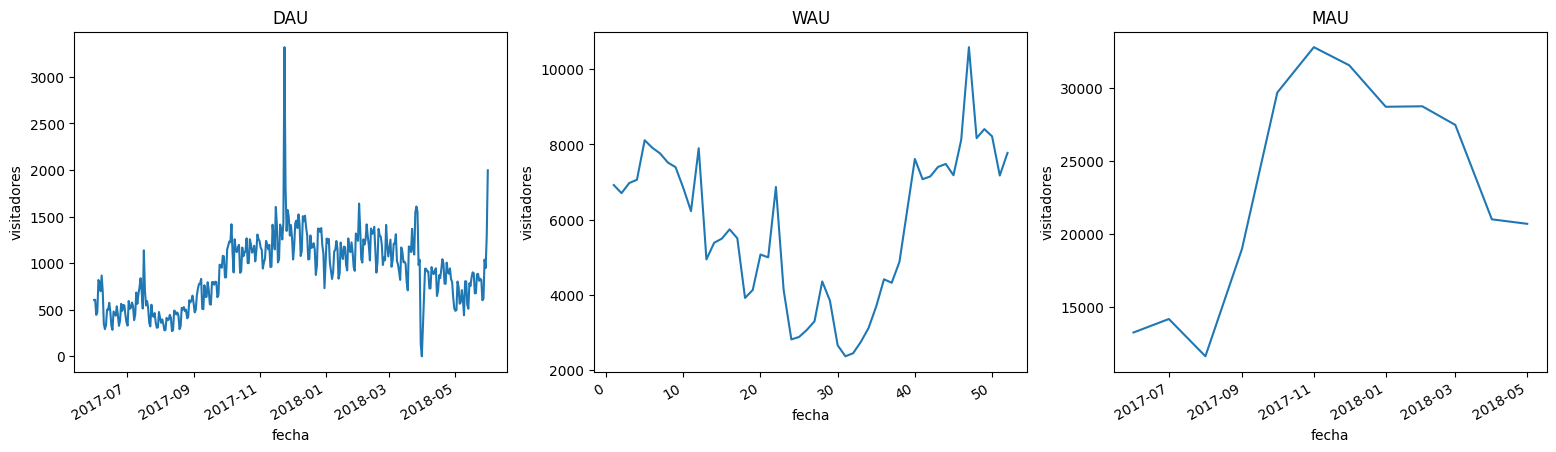

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(19,5))
ax[0].plot(dau)
ax[0].set(title='DAU', xlabel='fecha', ylabel='visitadores')
ax[1].plot(wau)
ax[1].set(title='WAU', xlabel='fecha', ylabel='visitadores')
ax[2].plot(mau)
ax[2].set(title='MAU', xlabel='fecha', ylabel='visitadores')
fig.autofmt_xdate(rotation=30)
plt.show()

## Número de sesiones por día

In [16]:
sesiones_por_usuario = visitas.groupby('sesion_fecha').agg({'uid': ['count', 'nunique']})
sesiones_por_usuario

uid        
             count nunique
sesion_fecha              
2017-06-01     664     605
2017-06-02     658     608
2017-06-03     477     445
2017-06-04     510     476
2017-06-05     893     820
...            ...     ...
2018-05-27     672     620
2018-05-28    1156    1039
2018-05-29    1035     948
2018-05-30    1410    1289
2018-05-31    2256    1997

[364 rows x 2 columns]

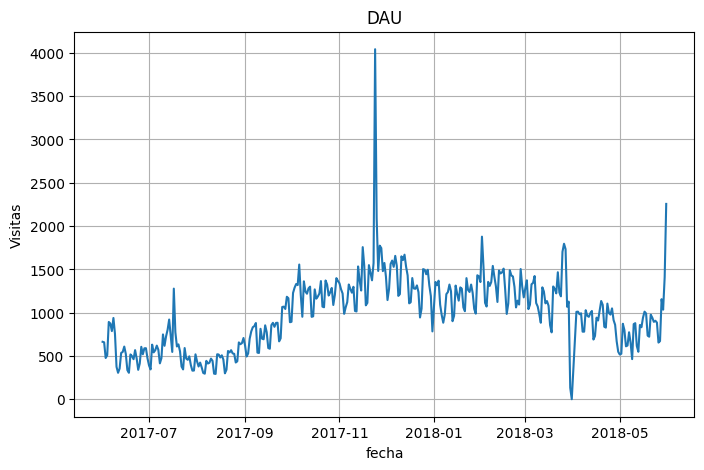

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(sesiones_por_usuario.index, sesiones_por_usuario[('uid', 'count')])
plt.title('DAU')
plt.xlabel('fecha')
plt.ylabel('Visitas')
plt.grid(True)
plt.show()

In [18]:
m.show_metrics(sesiones_por_usuario,('uid', 'count') )

Promedio: 987.3626373626373
Maximo: 4042
Minimo: 1
Std: 418.9947964852671


En promedio hay 987 sesiones por día. Viendo el gráfico y los valores estadísticos se puede afirmar que aunque los valores de sesiones por día se encuentran distribuidos en un mismo rango, existen algunos valores outliers como 1 y 4042. Hay días excepcionales donde el comportamiento de los usuarios implica un incremento o decremento de más de dos desviaciones estándar.

# Duración por sesión

In [19]:
visitas['duracion_sesion_seg'] = (visitas['end_ts'] - visitas['start_ts']).dt.seconds

In [20]:
visitas

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_sesion_seg
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27,0
...,...,...,...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017-07-01,30,2017-07-29,19
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018-01-01,4,2018-01-25,19
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018-03-01,9,2018-03-03,19
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017-11-01,44,2017-11-02,19


In [21]:
visitas['duracion_sesion_seg'].value_counts()

duracion_sesion_seg
60       53029
0        35794
120      35748
180      26672
240      21085
         ...  
17400        1
22440        1
32880        1
26220        1
12780        1
Name: count, Length: 312, dtype: int64

In [22]:
visitas['duracion_sesion_seg'].describe()

count    359400.000000
mean        643.506489
std        1016.334786
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       84480.000000
Name: duracion_sesion_seg, dtype: float64

Text(0, 0.5, 'Frecuencia')

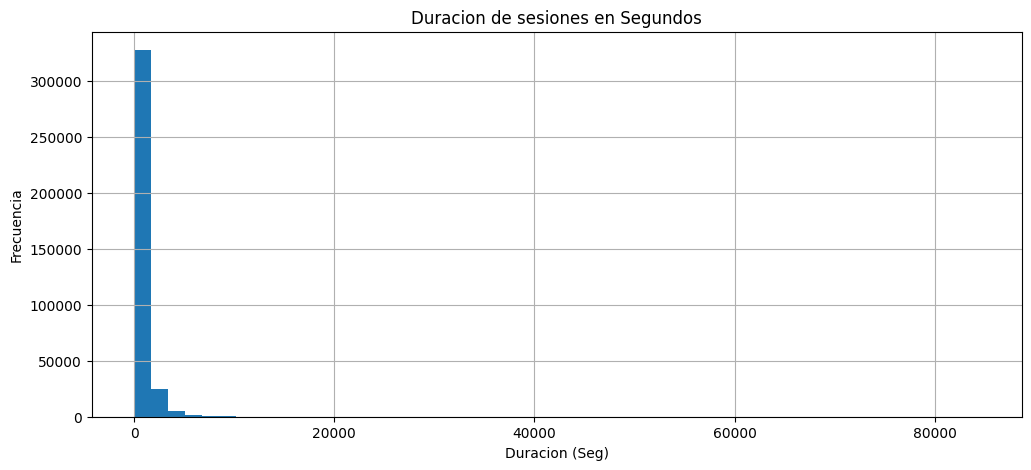

In [23]:
plt.figure(figsize=(12,5))
visitas['duracion_sesion_seg'].hist(bins=50)
plt.title('Duracion de sesiones en Segundos')
plt.xlabel('Duracion (Seg)')
plt.ylabel('Frecuencia')

In [24]:
m.show_metrics(visitas,'duracion_sesion_seg')

Promedio: 643.506488592098
Maximo: 84480
Minimo: 0
Std: 1016.3347859582315


Dado que el 75% de las sesiones duran menos de 840 seg, vamos a visualizar la distribución de sesiones qeu superan este tiempo

Text(0, 0.5, 'Frecuencia')

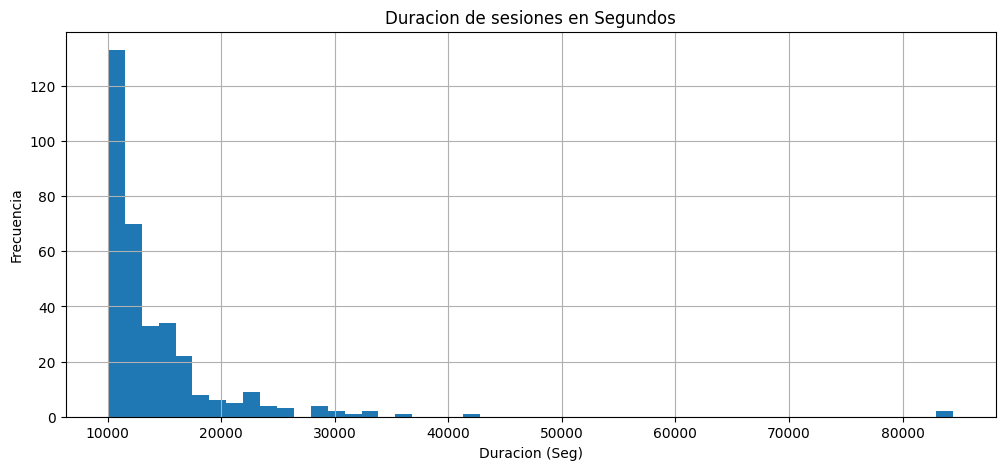

In [25]:
zoom_visitas = visitas[visitas['duracion_sesion_seg'] >= 10000]
plt.figure(figsize=(12,5))
zoom_visitas['duracion_sesion_seg'].hist(bins=50)
plt.title('Duracion de sesiones en Segundos')
plt.xlabel('Duracion (Seg)')
plt.ylabel('Frecuencia')

## Frecuencia de retorno

In [26]:
primeras_visitas = visitas.groupby('uid').agg({'start_ts': 'min'}).reset_index()
primeras_visitas.columns = ['uid', 'inicio_primera_sesion_ts']
primeras_visitas['primera_sesion_fecha'] = primeras_visitas['inicio_primera_sesion_ts'].dt.date
primeras_visitas['primera_sesion_mes'] = pd.to_datetime(primeras_visitas['inicio_primera_sesion_ts'].dt.strftime('%Y-%m-01'))

In [27]:
primeras_visitas

,uid,inicio_primera_sesion_ts,primera_sesion_fecha,primera_sesion_mes
0,11863502262781,2018-03-01 17:27:00,2018-03-01,2018-03-01
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2018-02-01
2,297729379853735,2017-06-07 18:47:00,2017-06-07,2017-06-01
3,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01
4,325320750514679,2017-09-30 14:29:00,2017-09-30,2017-09-01
...,...,...,...,...
228164,18446403737806311543,2017-11-30 03:36:00,2017-11-30,2017-11-01
228165,18446424184725333426,2017-12-06 20:32:00,2017-12-06,2017-12-01
228166,18446556406699109058,2018-01-01 16:29:00,2018-01-01,2018-01-01
228167,18446621818809592527,2017-12-27 13:27:00,2017-12-27,2017-12-01


In [28]:
visitas_full = pd.merge(primeras_visitas, visitas, on = 'uid', how='inner')

In [29]:
visitas_full['edad_meses'] = ((visitas_full['sesion_mes'] - visitas_full['primera_sesion_mes']) / (30 * np.timedelta64(1, 'D'))).round().astype('int')

In [30]:
visitas_full

,uid,inicio_primera_sesion_ts,primera_sesion_fecha,primera_sesion_mes,device,end_ts,source_id,start_ts,sesion_mes,sesion_semana,sesion_fecha,duracion_sesion_seg,edad_meses
0,11863502262781,2018-03-01 17:27:00,2018-03-01,2018-03-01,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,2018-03-01,9,2018-03-01,360,0
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2018-02-01,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,2018-02-01,6,2018-02-06,120,0
2,297729379853735,2017-06-07 18:47:00,2017-06-07,2017-06-01,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,2017-06-01,23,2017-06-07,60,0
3,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,2018-03-01,10,2018-03-11,360,6
4,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,2017-09-01,38,2017-09-18,1080,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
359395,18446424184725333426,2017-12-06 20:32:00,2017-12-06,2017-12-01,touch,2017-12-06 20:32:00,4,2017-12-06 20:32:00,2017-12-01,49,2017-12-06,0,0
359396,18446556406699109058,2018-01-01 16:29:00,2018-01-01,2018-01-01,touch,2018-01-01 16:31:00,3,2018-01-01 16:29:00,2018-01-01,1,2018-01-01,120,0
359397,18446621818809592527,2017-12-27 13:27:00,2017-12-27,2017-12-01,desktop,2018-05-21 09:45:00,4,2018-05-21 09:30:00,2018-05-01,21,2018-05-21,900,5
359398,18446621818809592527,2017-12-27 13:27:00,2017-12-27,2017-12-01,desktop,2017-12-27 14:08:00,4,2017-12-27 13:27:00,2017-12-01,52,2017-12-27,2460,0


In [31]:
cohortes_visitas = visitas_full.pivot_table(
    index='primera_sesion_mes',
    columns='edad_meses',
    values='uid',
    aggfunc='nunique'
)
cohortes_visitas.fillna(0, inplace=True)

In [32]:
cohortes_visitas

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_sesion_mes,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,0.0
2017-08-01,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,0.0,0.0
2017-09-01,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,0.0,0.0,0.0
2017-10-01,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,0.0,0.0,0.0,0.0
2017-11-01,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,0.0,0.0,0.0,0.0,0.0
2017-12-01,25268.0,1410.0,960.0,786.0,512.0,481.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-01,22624.0,1351.0,890.0,565.0,458.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-02-01,22197.0,1267.0,565.0,446.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset4/src/metricas.py:35: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  cohort_pivot.retention_pct = retention_pct


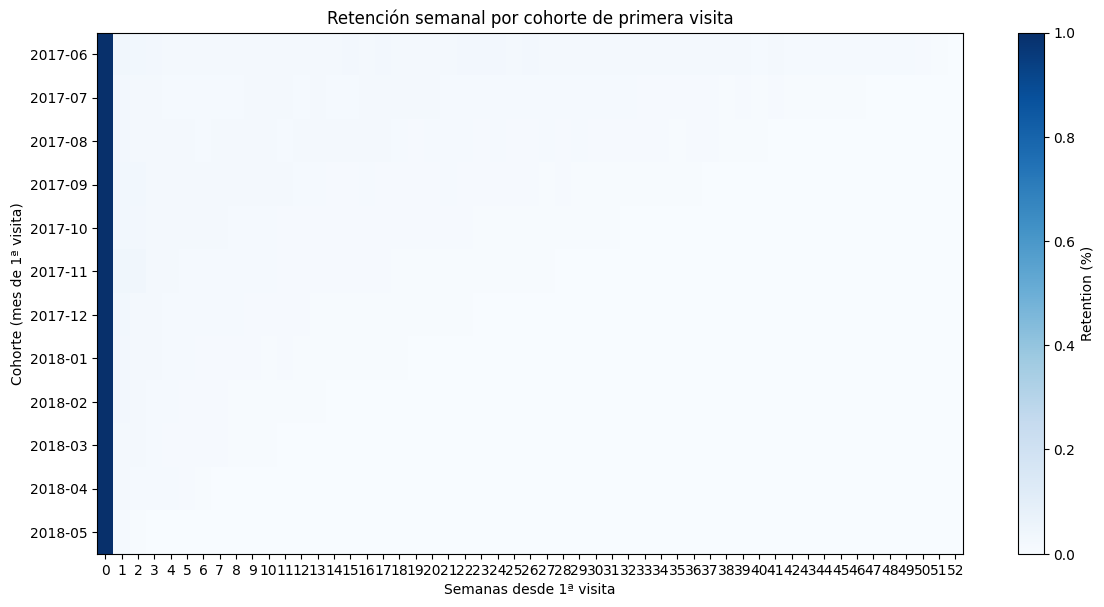

week_index,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
cohort_month,,,,,,,,,,,,,,,,,,,,,
2017-06,1.0,0.032,0.029,0.026,0.023,0.022,0.018,0.016,0.017,0.017,...,0.013,0.014,0.014,0.013,0.013,0.013,0.014,0.01,0.006,0.001
2017-07,1.0,0.024,0.019,0.016,0.015,0.015,0.015,0.014,0.014,0.016,...,0.007,0.007,0.006,0.004,0.001,0.000,0.000,0.00,0.000,0.000
2017-08,1.0,0.025,0.023,0.021,0.019,0.018,0.015,0.020,0.017,0.017,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000
2017-09,1.0,0.028,0.028,0.023,0.021,0.018,0.020,0.018,0.020,0.021,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000
2017-10,1.0,0.031,0.027,0.021,0.021,0.019,0.018,0.017,0.015,0.013,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000


In [33]:
# A.4 – Cohort Retention
cohort_table = m.cohort_analysis(visitas)

plt.figure(figsize=(12,6))
m.plot_retention(cohort_table)
plt.title('Retención semanal por cohorte de primera visita')
plt.show()

# Insight rápido
display(cohort_table.retention_pct.head())


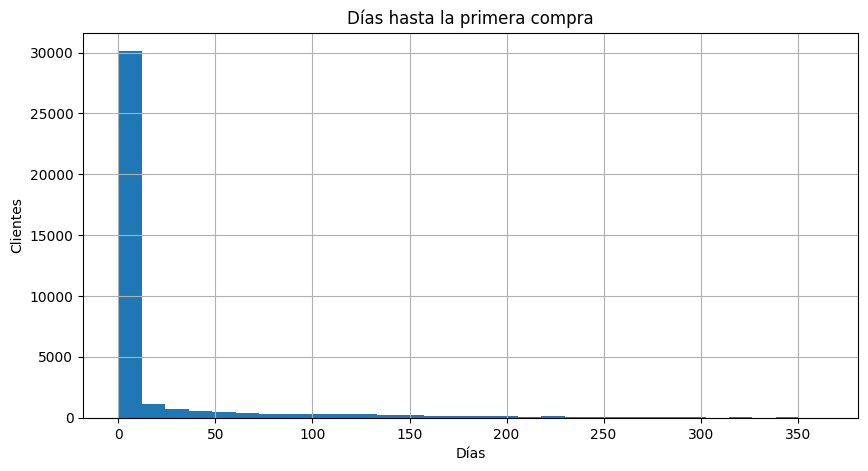

Mediana: 0 días  |  Promedio: 16.7 días


In [34]:
# Días entre primera visita y primera compra
conversion_days = m.days_to_first_purchase(visitas, ordenes)

plt.figure(figsize=(10,5))
conversion_days.hist(bins=30)
plt.title('Días hasta la primera compra')
plt.xlabel('Días')
plt.ylabel('Clientes')
plt.show()

print(f"Mediana: {conversion_days.median():.0f} días  |  Promedio: {conversion_days.mean():.1f} días")


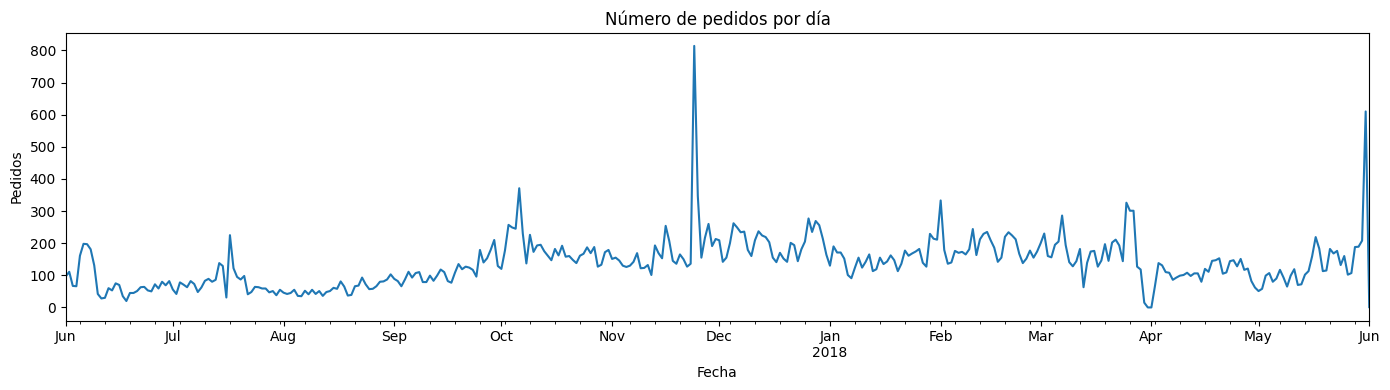

In [35]:
# Pedidos a lo largo del tiempo
orders_daily = m.orders_over_time(ordenes, freq='D')

plt.figure(figsize=(14,4))
orders_daily.plot()
plt.title('Número de pedidos por día')
plt.ylabel('Pedidos')
plt.xlabel('Fecha')
plt.tight_layout()
plt.show()


In [36]:
avg_ticket = ordenes['revenue'].mean()
print(f"Ticket promedio: ${avg_ticket:,.2f}")

Ticket promedio: $5.00


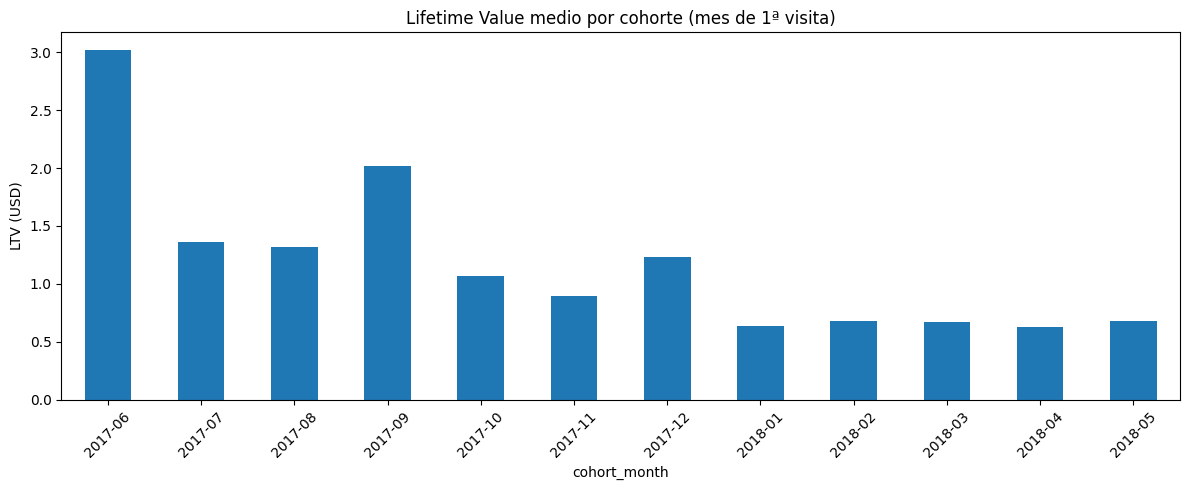

cohort_month
2017-06    3.02
2017-09    2.02
2017-07    1.36
2017-08    1.32
2017-12    1.23
Freq: M, dtype: float64

In [37]:
# LTV por cohorte
ltv = m.ltv_per_cohort(visitas, ordenes)

plt.figure(figsize=(12,5))
ltv.plot(kind='bar')
plt.ylabel('LTV (USD)')
plt.title('Lifetime Value medio por cohorte (mes de 1ª visita)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(ltv.sort_values(ascending=False).head())


# Métricas de Marketing

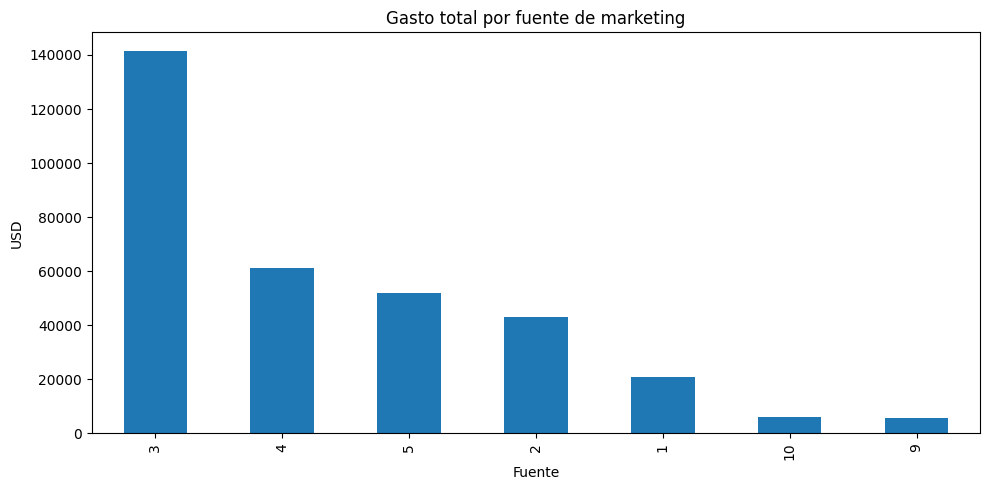

In [38]:
# Gastos totales y por fuente
gastos_por_fuente = costos.groupby('source_id')['costs'].sum()

plt.figure(figsize=(10,5))
gastos_por_fuente.sort_values(ascending=False).plot(kind='bar')
plt.title('Gasto total por fuente de marketing')
plt.ylabel('USD')
plt.xlabel('Fuente')
plt.tight_layout()
plt.show()

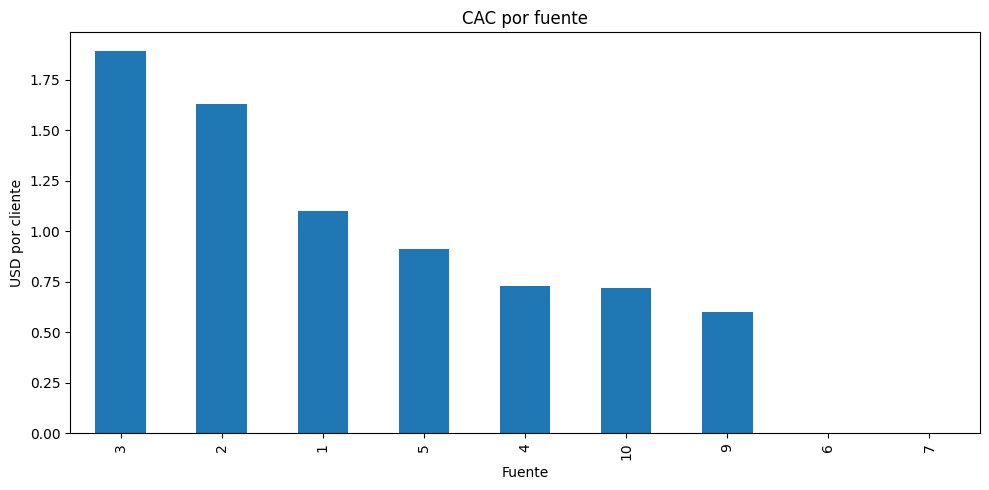

source_id
9     0.60
10    0.72
4     0.73
5     0.91
1     1.10
2     1.63
3     1.89
6      NaN
7      NaN
dtype: float64

In [39]:
# Customer Acquisition Cost (CAC) por fuente
cac = m.calculate_cac(visitas, costos)

plt.figure(figsize=(10,5))
cac.sort_values(ascending=False).plot(kind='bar')
plt.title('CAC por fuente')
plt.ylabel('USD por cliente')
plt.xlabel('Fuente')
plt.tight_layout()
plt.show()

display(cac.sort_values())

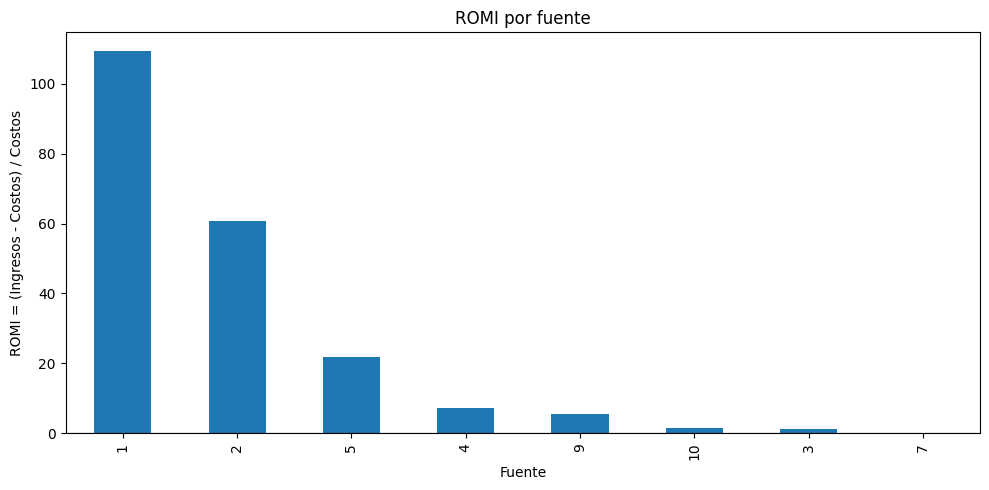

source_id
1     109.314
2      60.631
5      21.827
4       7.133
9       5.587
10      1.511
3       1.099
7         NaN
dtype: float64

In [40]:
# Return on Marketing Investment (ROMI)
romi = m.calculate_romi(visitas, ordenes, costos)

plt.figure(figsize=(10,5))
romi.sort_values(ascending=False).plot(kind='bar')
plt.title('ROMI por fuente')
plt.ylabel('ROMI = (Ingresos - Costos) / Costos')
plt.xlabel('Fuente')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

display(romi.sort_values(ascending=False))


## Conclusiones estratégicas

### 1. Fuentes ganadoras y perdedoras
* **Fuente 1** domina el desempeño con el CAC más competitivo y un ROMI superior a 100 . La mayor parte de los clientes de las primeras cohortes proviene de esta fuente y su LTV medio es alto.
* **Fuente 2** presenta un **equilibrio óptimo**: CAC bajo (< 1,6 USD) y ROMI cercano a 60. Su contribución crece en las cohortes de septiembre‑octubre.
* **Fuente 5** ofrece **buen margen de expansión**: CAC < 1 USD. Con inversión adicional y control de saturación podría escalar.
* **Fuente 3** consume el mayor presupuesto con **ROMI negativo** y el CAC más alto (1,9 USD). Mantenerla intacta destruye valor.
* Fuentes **6, 7, 9 y 10** tienen volúmenes marginales o nulos; pueden servir como experimentación, pero no impulsan el negocio principal.

### 2. Propuesta de presupuesto óptimo
1. **Trasladar un 30 % del gasto actual desde la Fuente 3 hacia 1, 2 y 5.**
2. **Duplicar la inversión en Fuente 1** y **aumentar 50 % en Fuente 2** para capitalizar su alto retorno.
3. **Incrementar gradualmente la Fuente 5**, midiendo CAC semanalmente
4. Mantener Fuente 4 estable, ya que sigue siendo rentable aunque de menor escala.


### 3. Supuestos y limitaciones
* El análisis utiliza **atribución de “primer clic”** (asignamos cada compra a la fuente de la primera sesión). No se consideran interacciones multicanal posteriores.
* La estimación de **LTV** se limita al horizonte de datos disponible. Si los clientes siguen comprando más allá, el valor real sería aún mayor.

### 4. Próximos pasos operativos
* Configurar **paneles en tiempo real** con CAC y ROMI por fuente para validar la nueva asignación.
* Implementar **campañas automáticas de remarketing** enfocadas en las primeras 48 h post‑registro.
* Revaluar mensualmente la Fuente 3; si no mejora su ROMI, cancelar definitivamente y redistribuir el presupuesto.


